In [13]:
import sys, os
sys.path.append('../data_extraction')

import matplotlib.pyplot as plt
import numpy as np

import cv2
from skimage.draw import disk

from LRO_data_class import getFilteredLabels, LunarDataset

In [ ]:
ds = LunarDataset()

dataDEM = ds.DEMLunarData
dataWAC = ds.regionalLunarData

filteredLabels = getFilteredLabels()

In [15]:
filteredLabels.head()

,CRATER_ID,LAT_CIRC_IMG,LON_CIRC_IMG,LAT_ELLI_IMG,LON_ELLI_IMG,DIAM_CIRC_IMG,DIAM_CIRC_SD_IMG,DIAM_ELLI_MAJOR_IMG,DIAM_ELLI_MINOR_IMG,DIAM_ELLI_ECCEN_IMG,...,DIAM_ELLI_ANGLE_IMG,LAT_ELLI_SD_IMG,LON_ELLI_SD_IMG,DIAM_ELLI_MAJOR_SD_IMG,DIAM_ELLI_MINOR_SD_IMG,DIAM_ELLI_ANGLE_SD_IMG,DIAM_ELLI_ECCEN_SD_IMG,DIAM_ELLI_ELLIP_SD_IMG,ARC_IMG,PTS_RIM_IMG
0,01-1-189527,59.99990,162.496,59.99990,162.496,1.76788,0.020729,1.79156,1.73944,0.239466,...,78.2722,0.000297,0.000611,0.020463,0.022637,20.55530,0.068162,0.017834,0.810232,11
1,01-1-189539,59.99710,123.437,60.00110,123.452,3.33136,0.098881,3.52154,2.56769,0.684365,...,118.2220,0.000456,0.001212,0.031186,0.051761,1.44716,0.017104,0.030197,0.680784,14
2,02-1-009148,1.22341,179.994,1.22345,179.994,4.33920,0.058872,4.46190,4.22970,0.318390,...,132.3200,0.000213,0.000213,0.016504,0.014545,3.23978,0.014254,0.005328,0.923478,42
3,02-1-033235,9.64757,179.997,9.66750,179.996,3.89968,0.179441,5.45599,3.62284,0.747722,...,92.0073,0.003449,0.000664,0.229611,0.035960,1.53257,0.025497,0.065117,0.760498,31
4,02-1-066872,18.74370,179.999,18.74420,179.999,1.99724,0.062144,2.13070,1.85889,0.488740,...,103.0210,0.000272,0.000262,0.019587,0.018319,3.30812,0.020988,0.015447,0.919424,24


In [ ]:
# Crop full DEM (60S–60N, 0–360°E) to tile bounds (0–60°N, 90–180°E)
# resolution = 128
# row 0 = 60°N
# row 60*128 = 0°N. 
# Col 90*128 = 90°E, 
# col 180*128 = 180°E

dataDEM = dataDEM.iloc[0:60*128, 90*128:180*128]
print(dataDEM.shape)

(7680, 11520)


## Patch extraction 

In [19]:
# [source]:  Silburt et al. (2019) - code

# Converting crater lat/lon to WAC pixel coordinates.
# LON_CIRC_IMG - 90: shifts longitude. 90°E = 0 (tile starts at 90°E, not 0°)
# * (dataWAC.shape[1] / 90): converts degrees to pixels.
# Shape[1]: total columns
# 90 is total degrees of longitude for the tile: pixels per degree for WAC
wac_col = (filteredLabels['LON_CIRC_IMG'] - 90) * (dataWAC.shape[1] / 90)
wac_row = (60 - filteredLabels['LAT_CIRC_IMG']) * (dataWAC.shape[0] / 60)

dem_col = (filteredLabels['LON_CIRC_IMG'] - 90) * (dataDEM.shape[1] / 90)
dem_row = (60 - filteredLabels['LAT_CIRC_IMG']) * (dataDEM.shape[0] / 60)

# Calculates how many DEM pixels correspond to 128 WAC pixels geographically.
dem_half = int(128 * dataDEM.shape[1] / dataWAC.shape[1])

stored_indices = []
wac_batch = []
dem_batch = []
batch_num = 0
batch_size = 1000

os.makedirs('patches', exist_ok=True)

# prevents randomness: background patches are the same every run
np.random.seed(42)

for i in range(len(filteredLabels)):

    wac_center_col = int(wac_col.iloc[i])
    wac_center_row = int(wac_row.iloc[i])

    # Scale WAC pixel coordinates to DEM pixel space using resolution ratio
    dem_center_col = int(wac_center_col * dataDEM.shape[1] / dataWAC.shape[1])
    dem_center_row = int(wac_center_row * dataDEM.shape[0] / dataWAC.shape[0])

    # prevent patches in borders
    if (wac_center_row - 128 < 0 or wac_center_row + 128 > dataWAC.shape[0] or
        wac_center_col - 128 < 0 or wac_center_col + 128 > dataWAC.shape[1] or
        dem_center_row - dem_half < 0 or dem_center_row + dem_half > dataDEM.shape[0] or
        dem_center_col - dem_half < 0 or dem_center_col + dem_half > dataDEM.shape[1]): continue

    wac_patch = dataWAC.values[wac_center_row-128:wac_center_row+128, wac_center_col-128:wac_center_col+128]
    dem_patch = dataDEM.values[dem_center_row-dem_half:dem_center_row+dem_half, dem_center_col-dem_half:dem_center_col+dem_half]

    if wac_patch.shape != (256, 256) or dem_patch.shape != (dem_half*2, dem_half*2):
      continue

    dem_patch = cv2.resize(dem_patch, (256, 256))

    wac_batch.append(wac_patch)
    dem_batch.append(dem_patch)

    stored_indices.append(i)

    if len(wac_batch) == batch_size:
        np.savez_compressed(f'patches/X_wac_{batch_num}', np.array(wac_batch))
        np.savez_compressed(f'patches/X_dem_{batch_num}', np.array(dem_batch))
        
        wac_batch = []
        dem_batch = []
        batch_num += 1

In [20]:
# Background patches for variability and diversity. 
# Better for model to distinguish between crater and non crater

# 25% of crater patches
n_background = len(stored_indices) // 4

for i in range(n_background):
    wac_rand_row = np.random.randint(128, dataWAC.shape[0] - 128)
    wac_rand_col = np.random.randint(128, dataWAC.shape[1] - 128)

    dem_rand_row = np.random.randint(dem_half, dataDEM.shape[0] - dem_half)
    dem_rand_col = np.random.randint(dem_half, dataDEM.shape[1] - dem_half)

    wac_patch = dataWAC.values[wac_rand_row-128:wac_rand_row+128, wac_rand_col-128:wac_rand_col+128]
    dem_patch = dataDEM.values[dem_rand_row-dem_half:dem_rand_row+dem_half, dem_rand_col-dem_half:dem_rand_col+dem_half]

    # from (dem_half*2, dem_half*2) = ~108×108
    # up to 256×256 to match the WAC patch size
    dem_patch = cv2.resize(dem_patch, (256, 256))

    if wac_patch.shape != (256, 256) or dem_patch.shape != (256, 256):
        continue

    wac_batch.append(wac_patch)
    dem_batch.append(dem_patch)

    stored_indices.append(-1)

    if len(wac_batch) == batch_size:
        np.savez_compressed(f'patches/X_wac_{batch_num}', np.array(wac_batch))
        np.savez_compressed(f'patches/X_dem_{batch_num}', np.array(dem_batch))
        
        wac_batch = []
        dem_batch = []
        batch_num += 1


In [21]:
if wac_batch:
    np.savez_compressed(f'patches/X_wac_{batch_num}', np.array(wac_batch))
    np.savez_compressed(f'patches/X_dem_{batch_num}', np.array(dem_batch))

filteredLabels['wac_col'] = wac_col.values
filteredLabels['wac_row'] = wac_row.values

kept_labels = filteredLabels.iloc[stored_indices].reset_index(drop=True)
kept_labels.to_csv('patches/kept_labels.csv', index=False)

In [ ]:
background_positions = []

for i, idx in enumerate(stored_indices):

    if (idx == -1):
        background_positions.append(i)

# Background patches have no crater label
# set to NaN to avoid misslabeling
kept_labels.loc[background_positions] = np.nan

batch_num_check = background_positions[0] // 1000

wac_check = np.load(f'patches/X_wac_{batch_num_check}.npz')['arr_0']
dem_check = np.load(f'patches/X_dem_{batch_num_check}.npz')['arr_0']

print(f'WAC batch shape: {wac_check.shape}')
print(f'DEM batch shape: {dem_check.shape}')

WAC batch shape: (1000, 256, 256)
DEM batch shape: (1000, 256, 256)


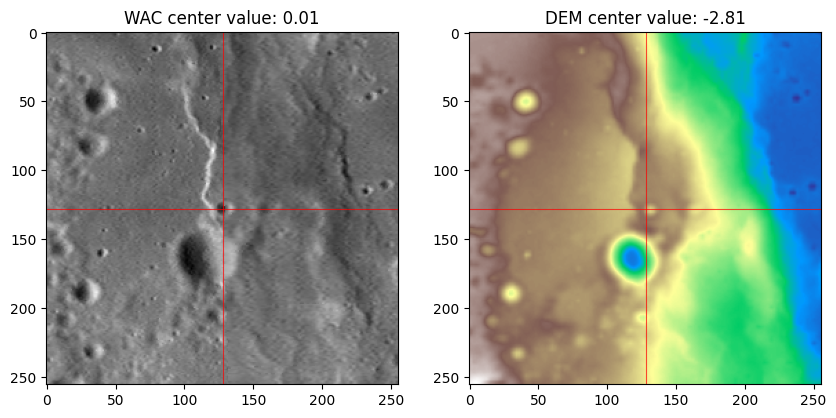

In [36]:
patch_idx = 100

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(wac_check[patch_idx], cmap='gray')
axes[0].axhline(128, color='r', linewidth=0.8, alpha=0.7)
axes[0].axvline(128, color='r', linewidth=0.8, alpha=0.7)
axes[0].set_title(f"WAC center value: {wac_check[patch_idx][128, 128]:.2f}")

axes[1].imshow(dem_check[patch_idx], cmap='terrain')
axes[1].axhline(128, color='r', linewidth=0.8, alpha=0.7)
axes[1].axvline(128, color='r', linewidth=0.8, alpha=0.7)
axes[1].set_title(f"DEM center value: {dem_check[patch_idx][128, 128]:.2f}")

plt.show()

## Mask generation 

In [ ]:
mask = np.zeros((256, 256), dtype=np.uint8)

for idx, crater in kept_labels.iterrows():
    
    if (wac_col - 128 <= crater['wac_col'] < wac_col + 128 and
        wac_row - 128 <= crater['wac_row'] < wac_row + 128):

        rel_col = int(crater['wac_col'] - (wac_col - 128))
        rel_row = int(crater['wac_row'] - (wac_row - 128))
        
        radius = int((crater['DIAM_CIRC_IMG'] / 2) / 0.1)

        rr, cc = disk((rel_row, rel_col), radius, shape=(256, 256))
        mask[rr, cc] = 1   

: 